Exercise 1

In [1]:
import math, random, time, statistics
from MP2_exercise import estimate_pi_serial

if __name__ == '__main__':
    random.seed(42)
    num_samples = 10000000
    times = []
    pies = []
    for _ in range(3):
        t0 = time.perf_counter()
        pi_estimate = estimate_pi_serial(num_samples)
        times.append(time.perf_counter() - t0)
        pies.append(pi_estimate)
        print(f"Run {_+1}:")
        print(f"pi estimate: {pi_estimate:.6f}")
        print(f"error: {abs(pi_estimate - math.pi):.6f}")
        print(f"Time: {time.perf_counter() - t0:.3f} s")

    t_serial = statistics.median(times)
    print("averages:")
    print(f"pi estimate: {statistics.median(pies):.6f} (error: {abs(statistics.median(pies)-math.pi):.6f})")
    print(f"Serial time: {t_serial:.3f}s")

Run 1:
pi estimate: 3.142310
error: 0.000717
Time: 1.158 s
Run 2:
pi estimate: 3.141866
error: 0.000273
Time: 1.070 s
Run 3:
pi estimate: 3.141505
error: 0.000087
Time: 1.014 s
averages:
pi estimate: 3.141866 (error: 0.000273)
Serial time: 1.070s


How accurate is the estimate? On average: 0.000273 with 3 runs and 10kk samples  
Run several times — does it vary? yes  
What is the serial time? 1.036seconds This will be your speedup denominator in E3.

In [2]:
from MP2_exercise import estimate_pi_parallel
import os, time, statistics, random

if __name__ == '__main__':
    random.seed(42)
    num_samples = 10_000_000
    for num_proc in range(1, os.cpu_count() + 1):
        times = []
        for _ in range(3):
            t0 = time.perf_counter()
            pi_est = estimate_pi_parallel(num_samples, num_proc)
            times.append(time.perf_counter() - t0)
        t = statistics.median(times)
        print(f"{num_proc:2d} workers: {t:.3f}s pi={pi_est:.6f}")

 1 workers: 1.095s pi=3.143146
 2 workers: 0.572s pi=3.141482
 3 workers: 0.402s pi=3.141490
 4 workers: 0.319s pi=3.141382
 5 workers: 0.272s pi=3.141230
 6 workers: 0.248s pi=3.141545
 7 workers: 0.263s pi=3.141772
 8 workers: 0.267s pi=3.142274


Do all worker counts give the same ˆπ? Why or why not? Monte Carlo uses random sampling  
At which count do you first see a meaningful speedup? from 1 to 2 workers halves the runtume, afterwards the gain is decreasing

1. At which worker count p∗is speedup maximum?  
$$S_6=1.061/0.239=4.44$$

2. Does speedup plateau or drop beyond p∗? Why?   
yes, at S_5<. Probably parallel overhead - process spawning, inter-process communication, task distribution, result collection, scheduling costs. Further it aligns with Amdahl's law.

3. Back-solve implied serial fraction: s = 1/Sp∗−1/p∗ / 1−1/p∗ — what fraction of time is effectively serial (IPC overhead + spawning)?  
$$s = ((1/4.44)-(1/6))/1-(1/6)=0.07$$

4. Mac M1/M2/M3 users: do you see a slope change near worker 8 (E-cores)?  
Yes, apparently M chips use performance cores and efficiency cores

Runtime: 0.051435 s


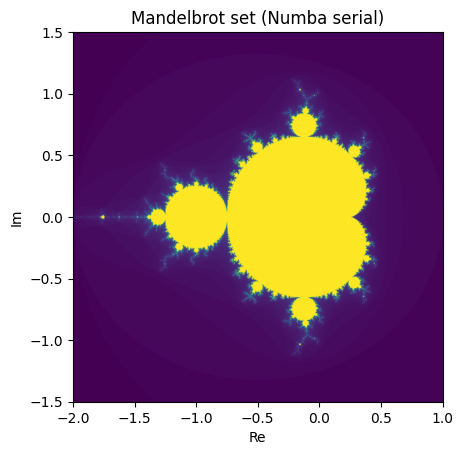

In [3]:
from mandelbrot import mandelbrot_serial
import matplotlib.pyplot as plt

grid_sizes = [1024]

max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5

width = grid_sizes[0]
height = grid_sizes[0]

warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_serial(*warm_args)

t0 = time.perf_counter()
numba_serial = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
t1 = time.perf_counter()

print(f"Runtime: {t1 - t0:.6f} s")

# plotting
plt.figure()
plt.imshow(numba_serial, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Numba serial)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.show()

Runtime: 0.946946 s


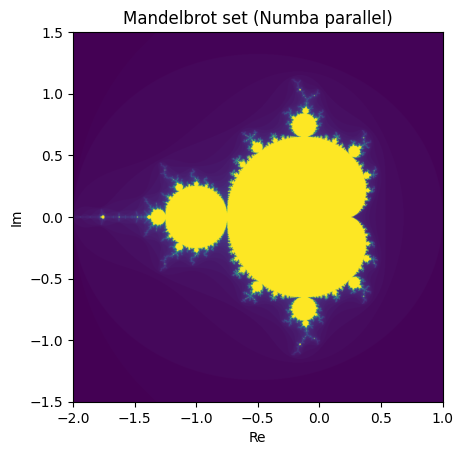

In [4]:
from mandelbrot import mandelbrot_parallel

width = 1024
height = 1024
max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5

# warmup
warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_serial(*warm_args)

t0 = time.perf_counter()
numba_parallel = mandelbrot_parallel(width, height, max_iter, xmin, xmax, ymin, ymax, 4)
t1 = time.perf_counter()

print(f"Runtime: {t1 - t0:.6f} s")

# plotting
plt.figure()
plt.imshow(numba_parallel, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Numba parallel)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.show()

In [5]:
import numpy as np
serial_img = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
parallel_img = mandelbrot_parallel(width, height, max_iter, xmin, xmax, ymin, ymax, 4)

print(np.array_equal(serial_img, parallel_img))

True


In [6]:
import os
import time
import statistics
import multiprocessing as mp

from mandelbrot import mandelbrot_serial, build_chunks, _worker_func


def time_serial_3x(width, height, max_iter, xmin, xmax, ymin, ymax):
    times = []

    for _ in range(3):
        t0 = time.perf_counter()
        img = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return statistics.median(times), img


def time_parallel_3x(width, height, max_iter, xmin, xmax, ymin, ymax, n_workers):
    times = []
    last_img = None

    chunks = build_chunks(width, height, max_iter, xmin, xmax, ymin, ymax, n_workers)

    with mp.Pool(processes=n_workers) as pool:
        warm_parts = pool.map(_worker_func, chunks)
        last_img = np.vstack(warm_parts)

        for _ in range(3):
            t0 = time.perf_counter()
            parts = pool.map(_worker_func, chunks)
            img = np.vstack(parts)
            t1 = time.perf_counter()

            times.append(t1 - t0)
            last_img = img

    return statistics.median(times), last_img


if __name__ == "__main__":
    width = 1024
    height = 1024
    max_iter = 100
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5

    mandelbrot_serial(256, 256, max_iter, xmin, xmax, ymin, ymax)

    t_serial, img_serial = time_serial_3x(width, height, max_iter, xmin, xmax, ymin, ymax)
    print(f"Serial median time: {t_serial:.6f} s")

    max_workers = os.cpu_count()

    for n_workers in range(1, max_workers + 1):
        t_parallel, img_parallel = time_parallel_3x(
            width, height, max_iter, xmin, xmax, ymin, ymax, n_workers
        )

        speedup = t_serial / t_parallel
        efficiency = speedup / n_workers
        matches = np.array_equal(img_serial, img_parallel)

        print(
            f"{n_workers:2d} workers | "
            f"tp = {t_parallel:.6f} s | "
            f"Sp = {speedup:.3f} | "
            f"Ep = {efficiency:.3f} | "
            f"match = {matches}"
        )

Serial median time: 0.052246 s
 1 workers | tp = 0.061747 s | Sp = 0.846 | Ep = 0.846 | match = True
 2 workers | tp = 0.033564 s | Sp = 1.557 | Ep = 0.778 | match = True
 3 workers | tp = 0.045110 s | Sp = 1.158 | Ep = 0.386 | match = True
 4 workers | tp = 0.028616 s | Sp = 1.826 | Ep = 0.456 | match = True
 5 workers | tp = 0.030941 s | Sp = 1.689 | Ep = 0.338 | match = True
 6 workers | tp = 0.023763 s | Sp = 2.199 | Ep = 0.366 | match = True
 7 workers | tp = 0.022711 s | Sp = 2.300 | Ep = 0.329 | match = True
 8 workers | tp = 0.018877 s | Sp = 2.768 | Ep = 0.346 | match = True


In [7]:
results = []

for n_workers in range(1, max_workers + 1):
    t_parallel, img_parallel = time_parallel_3x(
        width, height, max_iter, xmin, xmax, ymin, ymax, n_workers
    )

    speedup = t_serial / t_parallel
    efficiency = speedup / n_workers
    matches = np.array_equal(img_serial, img_parallel)

    results.append((n_workers, t_parallel, speedup, efficiency, matches))

for n_workers, t_parallel, speedup, efficiency, matches in results:
    print(
        f"{n_workers:2d} workers | "
        f"tp = {t_parallel:.6f} s | "
        f"Sp = {speedup:.3f} | "
        f"Ep = {efficiency:.3f} | "
        f"match = {matches}"
    )

 1 workers | tp = 0.058377 s | Sp = 0.895 | Ep = 0.895 | match = True
 2 workers | tp = 0.031715 s | Sp = 1.647 | Ep = 0.824 | match = True
 3 workers | tp = 0.042661 s | Sp = 1.225 | Ep = 0.408 | match = True
 4 workers | tp = 0.028221 s | Sp = 1.851 | Ep = 0.463 | match = True
 5 workers | tp = 0.029893 s | Sp = 1.748 | Ep = 0.350 | match = True
 6 workers | tp = 0.023187 s | Sp = 2.253 | Ep = 0.376 | match = True
 7 workers | tp = 0.022999 s | Sp = 2.272 | Ep = 0.325 | match = True
 8 workers | tp = 0.018868 s | Sp = 2.769 | Ep = 0.346 | match = True


MP2

Runtime: 0.042637 s


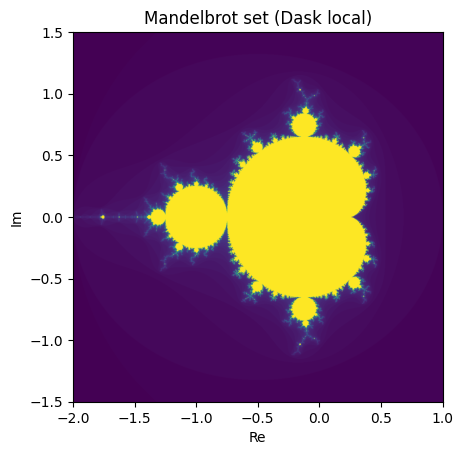

In [12]:
from dask.distributed import Client, LocalCluster
from mandelbrot import mandelbrot_dask, mandelbrot_chunk
import os
import time
import matplotlib.pyplot as plt

width = 1024
height = 1024
max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5
n_workers = min(8, os.cpu_count())
n_chunks = 32

cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1, dashboard_address=None)
client = Client(cluster)
client.run(mandelbrot_chunk, 0, 8, 8, 8, 10, xmin, xmax, ymin, ymax)

t0 = time.perf_counter()
dask_img = mandelbrot_dask(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks=n_chunks)
t1 = time.perf_counter()

print(f"Runtime: {t1 - t0:.6f} s")

plt.figure()
plt.imshow(dask_img, extent=(xmin, xmax, ymin, ymax), origin="lower")
plt.title("Mandelbrot set (Dask local)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.show()

client.close()
cluster.close()


In [13]:
from dask.distributed import Client, LocalCluster
from mandelbrot import mandelbrot_serial, mandelbrot_dask, mandelbrot_chunk
import numpy as np
import os

n_workers = min(8, os.cpu_count())
n_chunks = 32

cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1, dashboard_address=None)
client = Client(cluster)
client.run(mandelbrot_chunk, 0, 8, 8, 8, 10, xmin, xmax, ymin, ymax)

serial_img = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
dask_img = mandelbrot_dask(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks=n_chunks)

print(np.array_equal(serial_img, dask_img))

client.close()
cluster.close()


True


In [14]:
from dask.distributed import Client, LocalCluster
from mandelbrot import mandelbrot_dask, mandelbrot_chunk
import os
import statistics
import time

n_workers = min(8, os.cpu_count())
n_chunks = 32

times = []
cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1, dashboard_address=None)
client = Client(cluster)
client.run(mandelbrot_chunk, 0, 8, 8, 8, 10, xmin, xmax, ymin, ymax)

for _ in range(3):
    t0 = time.perf_counter()
    result = mandelbrot_dask(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks=n_chunks)
    times.append(time.perf_counter() - t0)

print(f"Dask local in_chunks=32 | {statistics.median(times):.3f} s")

client.close()
cluster.close()


Dask local in_chunks=32 | 0.054 s


n_chunks | time (s) | vs 1x | speedup | LIF
       1 |    0.076 |  1.00 |    1.00 |  7.00
       2 |    0.051 |  0.67 |    1.49 |  4.37
       4 |    0.047 |  0.61 |    1.64 |  3.89
       8 |    0.049 |  0.65 |    1.54 |  4.19
      16 |    0.054 |  0.71 |    1.41 |  4.67
      32 |    0.051 |  0.67 |    1.49 |  4.35
      64 |    0.080 |  1.04 |    0.96 |  7.35
     128 |    0.132 |  1.73 |    0.58 | 12.85

n_chunks_optimal = 4
t_min = 0.047 s
LIF_min = 3.890


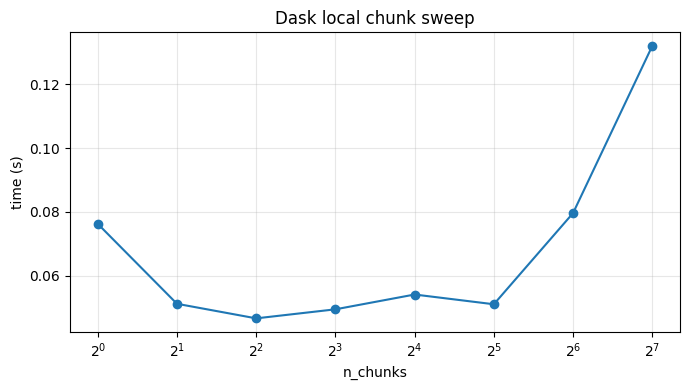

In [15]:
from dask.distributed import Client, LocalCluster
from mandelbrot import mandelbrot_serial, mandelbrot_dask, mandelbrot_chunk
import matplotlib.pyplot as plt
import numpy as np
import os
import statistics
import time


def time_dask_3x(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks):
    times = []
    last_img = None

    for _ in range(3):
        t0 = time.perf_counter()
        img = mandelbrot_dask(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks=n_chunks)
        t1 = time.perf_counter()

        times.append(t1 - t0)
        last_img = img

    return statistics.median(times), last_img


width = 1024
height = 1024
max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5
n_workers = min(8, os.cpu_count())
n_chunk_values = [n for n in [1, 2, 4, 8, 16, 32, 64, 128] if n <= height]

cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1, dashboard_address=None)
client = Client(cluster)
client.run(mandelbrot_chunk, 0, 8, 8, 8, 10, xmin, xmax, ymin, ymax)

serial_img = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
results = []
t_1x = None

print("n_chunks | time (s) | vs 1x | speedup | LIF")

for n_chunks in n_chunk_values:
    t_dask, img_dask = time_dask_3x(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks)
    assert np.array_equal(serial_img, img_dask)

    if t_1x is None:
        t_1x = t_dask

    vs_1x = t_dask / t_1x
    speedup = t_1x / t_dask
    lif = n_workers * t_dask / t_1x - 1

    results.append((n_chunks, t_dask, vs_1x, speedup, lif))
    print(f"{n_chunks:8d} | {t_dask:8.3f} | {vs_1x:5.2f} | {speedup:7.2f} | {lif:5.2f}")

n_chunks_optimal, t_min, _, _, lif_min = min(results, key=lambda item: item[1])
print()
print(f"n_chunks_optimal = {n_chunks_optimal}")
print(f"t_min = {t_min:.3f} s")
print(f"LIF_min = {lif_min:.3f}")

plt.figure(figsize=(7, 4))
plt.plot([row[0] for row in results], [row[1] for row in results], marker="o")
plt.xscale("log", base=2)
plt.xlabel("n_chunks")
plt.ylabel("time (s)")
plt.title("Dask local chunk sweep")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("dask_chunk_sweep.png", dpi=200)
plt.show()

client.close()
cluster.close()


In [16]:
from dask.distributed import Client, LocalCluster
from mandelbrot import (
    mandelbrot_naive,
    mandelbrot_numpy,
    mandelbrot_numba_basic,
    mandelbrot_serial,
    mandelbrot_parallel,
    mandelbrot_dask,
    mandelbrot_chunk,
)
import multiprocessing as mp
import numpy as np
import os
import statistics
import time


def time_func_3x(func, *args, **kwargs):
    times = []
    last_img = None

    for _ in range(3):
        t0 = time.perf_counter()
        last_img = func(*args, **kwargs)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    return statistics.median(times), last_img


width = 1024
height = 1024
max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5
n_workers = min(8, os.cpu_count())
n_chunks = 8
args = (width, height, max_iter, xmin, xmax, ymin, ymax)
warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)

mandelbrot_numba_basic(*warm_args)
mandelbrot_serial(*warm_args)

t_naive, img_naive = time_func_3x(mandelbrot_naive, *args)
ref_img = np.array(img_naive)

t_numpy, img_numpy = time_func_3x(mandelbrot_numpy, *args)
assert np.array_equal(ref_img, img_numpy)

t_numba, img_numba = time_func_3x(mandelbrot_serial, *args)
assert np.array_equal(ref_img, img_numba)

with mp.Pool(processes=n_workers) as pool:
    mandelbrot_parallel(*args, n_workers=n_workers, pool=pool)
    t_mp, img_mp = time_func_3x(
        mandelbrot_parallel, *args, n_workers=n_workers, pool=pool
    )
assert np.array_equal(ref_img, img_mp)

cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1, dashboard_address=None)
client = Client(cluster)
client.run(mandelbrot_chunk, 0, 8, 8, 8, 10, xmin, xmax, ymin, ymax)

t_dask, img_dask = time_func_3x(mandelbrot_dask, *args, n_chunks=n_chunks)
client.close()
cluster.close()
assert np.array_equal(ref_img, img_dask)

results = [
    ("Naive Python", t_naive),
    ("NumPy", t_numpy),
    ("Numba (@njit)", t_numba),
    ("Numba + multiprocessing", t_mp),
    ("Dask local", t_dask),
]

print(f"n_workers = {n_workers}")
print(f"n_chunks = {n_chunks}")
print("Implementation | Time (s) | Speedup vs. naive")

for name, t in results:
    speedup = t_naive / t
    print(f"{name} | {t:.3f} | {speedup:.2f}x")


n_workers = 8
n_chunks = 8
Implementation | Time (s) | Speedup vs. naive
Naive Python | 2.843 | 1.00x
NumPy | 0.747 | 3.81x
Numba (@njit) | 0.055 | 52.14x
Numba + multiprocessing | 0.020 | 143.54x
Dask local | 0.040 | 70.91x


MP2 M3: Full benchmark added?  
Yes

Implementation | Time (s) | Speedup vs. naive  
Naive Python | 2.931 | 1.00x  
NumPy | 0.680 | 4.31x  
Numba (@njit) | 0.055 | 52.99x  
Numba + multiprocessing | 0.021 | 138.47x  
Dask local | 0.044 | 66.58x

At the same worker count on this machine, Dask local was slower than multiprocessing but still much faster than naive and NumPy.


MP2 M1 on Strato  
These cells assume the Dask scheduler is already running on the head node and workers are started manually on the worker VMs, as described in your Strato guide.


In [ ]:
from dask.distributed import Client
from mandelbrot import mandelbrot_serial, mandelbrot_dask, mandelbrot_chunk
import matplotlib.pyplot as plt
import numpy as np
import statistics
import time

scheduler_address = "tcp://10.92.1.110:8786"
width = 4096
height = 4096
max_iter = 100
xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5
n_chunk_values = [4, 8, 16, 32, 64, 128, 256]


def version_info():
    import dask
    import distributed
    import numpy
    import socket
    import sys

    return {
        "host": socket.gethostname(),
        "python": sys.version.split()[0],
        "numpy": numpy.__version__,
        "dask": dask.__version__,
        "distributed": distributed.__version__,
    }


def warmup_worker():
    return mandelbrot_chunk(0, 8, 8, 8, 10, xmin, xmax, ymin, ymax)


def time_serial_3x(width, height, max_iter, xmin, xmax, ymin, ymax):
    times = []
    last_img = None

    for _ in range(3):
        t0 = time.perf_counter()
        img = mandelbrot_serial(width, height, max_iter, xmin, xmax, ymin, ymax)
        t1 = time.perf_counter()
        times.append(t1 - t0)
        last_img = img

    return statistics.median(times), last_img


def time_dask_3x(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks):
    times = []
    last_img = None

    for _ in range(3):
        t0 = time.perf_counter()
        img = mandelbrot_dask(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks=n_chunks)
        t1 = time.perf_counter()
        times.append(t1 - t0)
        last_img = img

    return statistics.median(times), last_img


client = Client(scheduler_address)
print(client)
print(client.run(version_info))


In [ ]:
warm_args = (256, 256, max_iter, xmin, xmax, ymin, ymax)
mandelbrot_serial(*warm_args)
client.run(warmup_worker)

worker_processes = len(client.scheduler_info()["workers"])
print(f"Connected worker processes: {worker_processes}")

t_serial, serial_img = time_serial_3x(width, height, max_iter, xmin, xmax, ymin, ymax)
print(f"Serial Numba baseline: {t_serial:.3f} s")


In [ ]:
worker_processes = len(client.scheduler_info()["workers"])
print(f"Connected worker processes: {worker_processes}")

chunk_results = []
t_1x = None

print("n_chunks | time (s) | vs 1x | speedup | LIF")

for n_chunks in n_chunk_values:
    t_dask, dask_img = time_dask_3x(width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks)
    assert np.array_equal(serial_img, dask_img)

    if t_1x is None:
        t_1x = t_dask

    vs_1x = t_dask / t_1x
    speedup = t_1x / t_dask
    lif = worker_processes * t_dask / t_1x - 1

    chunk_results.append((n_chunks, t_dask, vs_1x, speedup, lif))
    print(f"{n_chunks:8d} | {t_dask:8.3f} | {vs_1x:5.2f} | {speedup:7.2f} | {lif:5.2f}")

n_chunks_optimal, t_min, _, _, lif_min = min(chunk_results, key=lambda item: item[1])
print()
print(f"n_chunks_optimal = {n_chunks_optimal}")
print(f"t_min = {t_min:.3f} s")
print(f"LIF_min = {lif_min:.3f}")
print(f"speedup vs serial = {t_serial / t_min:.2f}x")

plt.figure(figsize=(7, 4))
plt.plot([row[0] for row in chunk_results], [row[1] for row in chunk_results], marker="o")
plt.xscale("log", base=2)
plt.xlabel("n_chunks")
plt.ylabel("time (s)")
plt.title("Strato Dask chunk sweep")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("strato_chunk_sweep.png", dpi=200)
plt.show()


In [ ]:
if "worker_scaling" not in globals():
    worker_scaling = []

worker_processes = len(client.scheduler_info()["workers"])
client.run(warmup_worker)

t_dask, dask_img = time_dask_3x(
    width, height, max_iter, xmin, xmax, ymin, ymax, n_chunks_optimal
)
assert np.array_equal(serial_img, dask_img)

worker_scaling = [row for row in worker_scaling if row[0] != worker_processes]
worker_scaling.append((worker_processes, t_dask, t_serial / t_dask))
worker_scaling.sort(key=lambda row: row[0])

print("worker processes | time (s) | speedup vs serial")
for workers, t_wall, speedup in worker_scaling:
    print(f"{workers:16d} | {t_wall:8.3f} | {speedup:17.2f}x")

plt.figure(figsize=(7, 4))
plt.plot([row[0] for row in worker_scaling], [row[1] for row in worker_scaling], marker="o")
plt.xlabel("worker processes")
plt.ylabel("time (s)")
plt.title("Strato Dask worker scaling")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("strato_worker_scaling.png", dpi=200)
plt.show()


Run order on the head node:  
1. Start `dask scheduler` in `tmux` and start workers on the worker VMs.  
2. Run the connect/version cell and confirm `client.run(version_info)` matches on all workers.  
3. Run the serial baseline cell once.  
4. Run the chunk sweep cell with all worker VMs connected and note `n_chunks_optimal`.  
5. For worker scaling, start with one worker VM connected, run the worker-scaling cell, add another worker VM, and rerun the same cell.  
6. When finished, run `client.close()` in a final cell or restart the kernel.
